Total calls: 3519
Average calls per day: 117.3
Median calls per day: 117.0
STD calls: 9.31
Total resolved: 2699
Overall resolution rate: 76.7 %
Average duration: 5.6 minutes
Q1 total minutes: 576.24
Q2 / Median total minutes: 660.78
Q3 total minutes: 749.36
90th percentile total minutes: 856.7
Heavy workload days: [ 1 12 30]
Heavy workload minutes: [902.48 868.73 913.32]
Top 3 busiest days: [30  1 12]
Top 3 total minutes: [913.32 902.48 868.73]


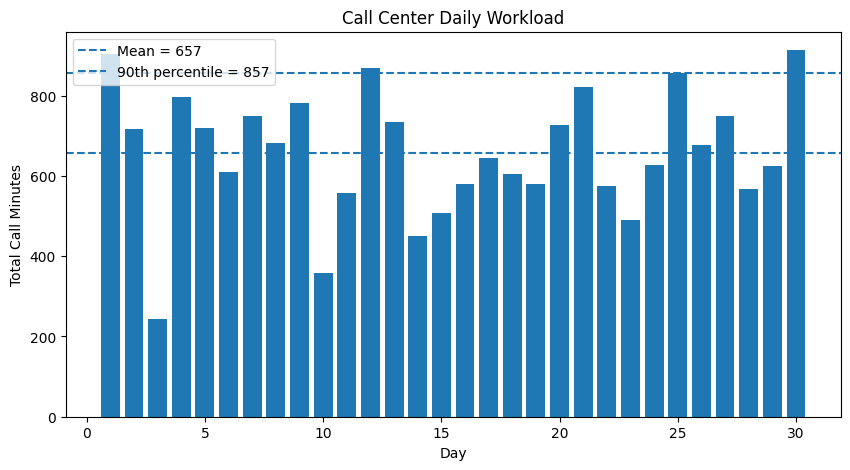

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# EVENT: 30 kunlik call center data

days = np.arange(1, 31)

# Poisson: har kuni nechta call keladi?
calls = np.random.poisson(lam=120, size=30)

# Binomial: kelgan calllardan nechtasi hal bo'ladi?
resolved = np.random.binomial(n=calls, p=0.76)

# Normal: har kungi average call duration
duration = np.random.normal(loc=6, scale=1.4, size=30)
duration = np.clip(duration, 1, None)
duration = np.round(duration, 2)

# Basic metrics
unresolved = calls - resolved
resolution_rate = resolved / calls * 100
total_minutes = calls * duration

# Mean, Median, STD
print("Total calls:", calls.sum())
print("Average calls per day:", round(calls.mean(), 2))
print("Median calls per day:", np.median(calls))
print("STD calls:", round(calls.std(), 2))

print("Total resolved:", resolved.sum())
print("Overall resolution rate:", round(resolved.sum() / calls.sum() * 100, 2), "%")
print("Average duration:", round(duration.mean(), 2), "minutes")

# Percentile / Quartile
q1 = np.percentile(total_minutes, 25)
q2 = np.percentile(total_minutes, 50)
q3 = np.percentile(total_minutes, 75)
p90 = np.percentile(total_minutes, 90)

print("Q1 total minutes:", round(q1, 2))
print("Q2 / Median total minutes:", round(q2, 2))
print("Q3 total minutes:", round(q3, 2))
print("90th percentile total minutes:", round(p90, 2))

# Boolean Masking: heavy workload days
heavy_days = days[total_minutes >= p90]
heavy_minutes = total_minutes[total_minutes >= p90]

print("Heavy workload days:", heavy_days)
print("Heavy workload minutes:", np.round(heavy_minutes, 2))

# Fancy Indexing: top 3 busiest days
top3_idx = np.argsort(total_minutes)[-3:][::-1]

print("Top 3 busiest days:", days[top3_idx])
print("Top 3 total minutes:", np.round(total_minutes[top3_idx], 2))

# Visualization
plt.figure(figsize=(10, 5))
plt.bar(days, total_minutes)

plt.axhline(total_minutes.mean(), linestyle="--", label=f"Mean = {total_minutes.mean():.0f}")
plt.axhline(p90, linestyle="--", label=f"90th percentile = {p90:.0f}")

plt.title("Call Center Daily Workload")
plt.xlabel("Day")
plt.ylabel("Total Call Minutes")
plt.legend()
plt.show()